In [6]:
import numpy as np
import matplotlib.pyplot as plt

Матрица P^1000 (предельное состояние):
[[0.20671  0.302858 0.28957  0.200861]
 [0.20671  0.302858 0.28957  0.200861]
 [0.20671  0.302858 0.28957  0.200861]
 [0.20671  0.302858 0.28957  0.200861]]

Стационарное распределение (любая строка P^1000):
A: 0.206710
C: 0.302858
G: 0.289570
T: 0.200861


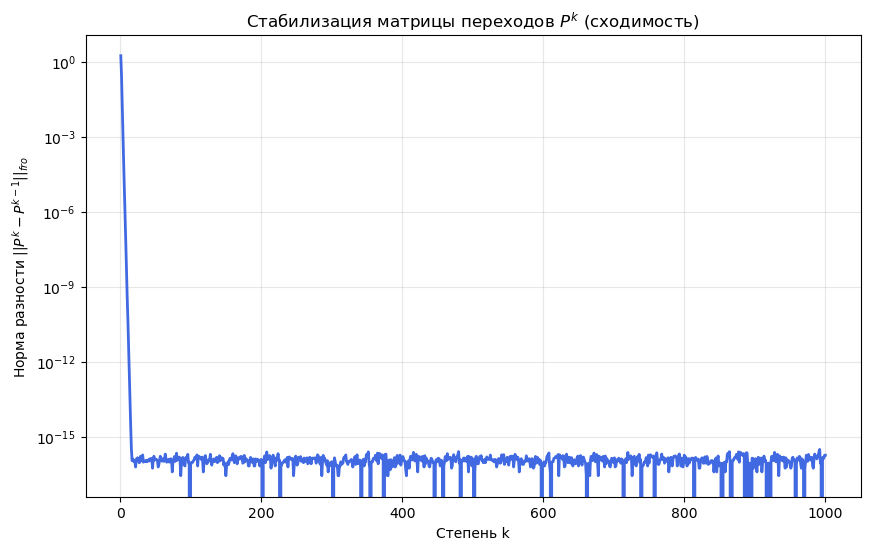

In [7]:
P = np.array([
    [0.224, 0.248, 0.390, 0.138],
    [0.251, 0.360, 0.101, 0.288],
    [0.197, 0.300, 0.341, 0.162],
    [0.136, 0.277, 0.396, 0.190]
])
P = P / P.sum(axis=1)[:, np.newaxis]

ks = np.arange(1, 1001)
norms = []
P_prev = np.eye(4)

for k in ks:
    P_k = np.linalg.matrix_power(P, k)
    diff_norm = np.linalg.norm(P_k - P_prev, ord='fro')
    norms.append(diff_norm)
    P_prev = P_k

plt.figure(figsize=(10, 6))
plt.plot(ks, norms, color='royalblue', linewidth=2)
plt.yscale('log')
plt.title('Стабилизация матрицы переходов $P^k$ (сходимость)')
plt.xlabel('Степень k')
plt.ylabel('Норма разности $||P^k - P^{k-1}||_{fro}$')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.savefig('stabilization_plot.png')

P_1000 = np.linalg.matrix_power(P, 1000)
print("Матрица P^1000 (предельное состояние):")
print(np.round(P_1000, 6))

print("\nСтационарное распределение (любая строка P^1000):")
nucs = ['A', 'C', 'G', 'T']
for n, p in zip(nucs, P_1000[0]):
    print(f"{n}: {p:.6f}")